## Video-based Emotion Classification with Ordinal-Aware Triplet Learning

This notebook implements a two-stage training pipeline for video-based emotion classification using Transformer models.

Stage 1: Triplet Loss Pre-training A TransformerEmbeddingExtractor is trained using an ordinal-aware triplet loss. This stage aims to learn robust video embeddings by pulling same-class embeddings closer and pushing different-class embeddings apart, with a special emphasis on respecting the ordinal relationship between labels (e.g., varying degrees of emotion intensity or depression severity).

Stage 2: Classification Head Training A lightweight classification head (a simple Multi-Layer Perceptron) is trained on top of the frozen, pre-trained Transformer embeddings. This stage performs the final classification task on the learned features.

The notebook covers the entire process, including:

Extracting face embeddings from video frames using InsightFace and saving them to CSVs.
Custom VideoEmbeddingDataset and data loaders to handle variable-length video sequences.
Implementation of ordinal-aware triplet mining and cosine triplet loss.
Full training and evaluation loops for both the triplet loss stage and the classification stage.
Evaluation metrics such as intra-class/inter-class similarity, classification reports, and confusion matrices.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import os
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
Base_dir = "/content/drive/MyDrive/Timesformer_temp"
if os.path.exists(Base_dir):
  print("y")

y


In [ ]:
! pip install insightface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 91.2 MB/s eta 0:00:00


In [ ]:
from insightface.app import FaceAnalysis
import cv2

app = FaceAnalysis(name='buffalo_l')  # ArcFace pretrained pack
app.prepare(ctx_id=0)  # 0 = GPU, -1 = CPU

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:04<00:00, 56806.86KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: [(128, 128), (640, 640)

In [ ]:
import numpy as np
import pandas as pd
import os
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
# path = "C:\\Users\\Shweta\\Timesformer_temp"
video_path = Base_dir
x=(os.listdir(os.path.join(video_path,'01-01-08-02-02-01-24')))
x

['frame0001.png',
 'frame0002.png',
 'frame0003.png',
 'frame0004.png',
 'frame0005.png',
 'frame0006.png',
 'frame0007.png',
 'frame0008.png',
 'frame0009.png',
 'frame0010.png',
 'frame0011.png',
 'frame0012.png',
 'frame0013.png',
 'frame0014.png',
 'frame0015.png',
 'frame0016.png',
 'frame0017.png',
 'frame0018.png',
 'frame0019.png',
 'frame0020.png',
 'frame0021.png',
 'frame0022.png',
 'frame0023.png',
 'frame0024.png',
 'frame0025.png',
 'frame0026.png',
 'frame0027.png',
 'frame0028.png',
 'frame0029.png',
 'frame0030.png',
 'frame0031.png',
 'frame0032.png',
 'frame0033.png',
 'frame0034.png',
 'frame0035.png',
 'frame0036.png',
 'frame0037.png',
 'frame0038.png',
 'frame0039.png',
 'frame0040.png',
 'frame0041.png',
 'frame0042.png',
 'frame0043.png',
 'frame0044.png',
 'frame0045.png',
 'frame0046.png',
 'frame0047.png',
 'frame0048.png',
 'frame0049.png',
 'frame0050.png',
 'frame0051.png',
 'frame0052.png',
 'frame0053.png',
 'frame0054.png',
 'frame0055.png',
 'frame005

In [ ]:
len(os.listdir(video_path))

56

In [ ]:
# extract video_embeddings of all frames in a video and save them in a csv file
import os
import cv2
skip_dirs = [
    "01-01-01-01-01-01-01",
    "01-01-01-01-01-01-02",
    "01-01-01-01-01-01-03",
    "01-01-01-01-01-01-07",
    "01-01-01-01-01-01-08",
    "01-01-01-01-01-01-09",
    "01-01-01-01-01-01-11",
]
for video in os.listdir(video_path):
    if video in skip_dirs:
        print(f"Skipping video: {video}")
        continue
    print(f"Processing video: {video}")
    curr_video_path = os.path.join(video_path, video)
    all_frames = os.listdir(curr_video_path)
    embeddings = []
    print(f"Processing video: {video}")
    for frame in all_frames[1:]:
            print(f"Processing frame: {frame}")
            img = cv2.imread(os.path.join(curr_video_path, frame))
            faces = app.get(img)
            print(f"Number of faces detected: {len(faces)}")
            for face in faces:
                embedding = face.embedding
                embeddings.append(embedding)
                print(f"Added embedding number: {len(embeddings)}")
    # save embeddings in a csv file
    df = pd.DataFrame(embeddings)
    df.to_csv(video + ".csv", index=False)

Streaming output truncated to the last 5000 lines.
Added embedding number: 105
Processing frame: frame0107.png
Number of faces detected: 1
Added embedding number: 106
Processing frame: frame0108.png
Number of faces detected: 1
Added embedding number: 107
Processing frame: frame0109.png
Number of faces detected: 1
Added embedding number: 108
Processing frame: frame0110.png
Number of faces detected: 1
Added embedding number: 109
Processing frame: frame0111.png
Number of faces detected: 1
Added embedding number: 110
Processing frame: frame0112.png
Number of faces detected: 1
Added embedding number: 111
Processing frame: frame0113.png
Number of faces detected: 1
Added embedding number: 112
Processing frame: frame0114.png
Number of faces detected: 1
Added embedding number: 113
Processing video: 01-01-05-02-02-01-17
Processing video: 01-01-05-02-02-01-17
Processing frame: frame0002.png
Number of faces detected: 1
Added embedding number: 1
Processing frame: frame0003.png
Number of faces detec

KeyboardInterrupt: 

In [ ]:
# save all the files stored in the session storage
from google.colab import files
import os
import zipfile
from google.colab import files

zip_path = "/content/csv_only.zip"

with zipfile.ZipFile(zip_path, 'w') as zipf:
    for file in os.listdir("/content"):
        if file.endswith(".csv"):
            zipf.write(os.path.join("/content", file), file)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
"""
Triplet Loss Training for TransformerEmbeddingExtractor
=======================================================
Trains your Transformer to pull same-label video embeddings closer
and push different-label embeddings apart in cosine space.

Ordinal-aware triplet mining is included — PHQ class 0 vs 1 are treated
as "closer" than 0 vs 4, which respects your depression severity structure.
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from itertools import combinations


# ──────────────────────────────────────────────
# 1. YOUR EXISTING MODEL (unchanged)
# ──────────────────────────────────────────────

class TransformerEmbeddingExtractor(nn.Module):
    def __init__(self, input_dim=512, embed_dim=768, num_heads=12, num_layers=4):
        super().__init__()
        self.proj = nn.Linear(input_dim, embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(0)                           # (1, T, 512)
        x = self.proj(x)                                  # (B, T, 768)
        batch_size = x.size(0)
        cls = self.cls_token.unsqueeze(0).expand(batch_size, -1, -1)  # (B,1,768)
        x = torch.cat([cls, x], dim=1)                   # (B, T+1, 768)
        x = self.encoder(x)
        return x[:, 0]                                    # (B, 768)

In [ ]:
# ──────────────────────────────────────────────
# 2. DATASET
# Expects a folder of CSVs where each CSV = one video's frame embeddings.
# Labels are passed in via a dict: {csv_filename_stem: phq_class (0-4)}
# ──────────────────────────────────────────────

class VideoEmbeddingDataset(Dataset):
    """
    csv_dir  : folder containing per-video ArcFace embedding CSVs
    label_map: dict mapping filename stem → integer label (0–4 for PHQ severity)

    If you don't have labels yet, pass label_map=None and all samples
    will get label 0 (useful for sanity-checking the pipeline).
    """
    def __init__(self, csv_dir: str, label_map: dict = None):
        self.samples = []   # list of (tensor, label)

        for fname in sorted(os.listdir(csv_dir)):
            if not fname.endswith(".csv"):
                continue
            stem = fname.replace(".csv", "")
            label = label_map[stem] if (label_map and stem in label_map) else 0

            arr = pd.read_csv(os.path.join(csv_dir, fname)).values
            tensor = torch.tensor(arr, dtype=torch.float32)   # (T, 512)
            self.samples.append((tensor, label))

        print(f"Loaded {len(self.samples)} videos from {csv_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]   # (tensor, label)


def collate_variable_length(batch):
    """Pad sequences to the longest in the batch."""
    tensors, labels = zip(*batch)
    max_len = max(t.shape[0] for t in tensors)
    padded = torch.zeros(len(tensors), max_len, tensors[0].shape[1])
    for i, t in enumerate(tensors):
        padded[i, :t.shape[0]] = t
    return padded, torch.tensor(labels, dtype=torch.long)

In [ ]:
# ──────────────────────────────────────────────
# 3. ORDINAL-AWARE TRIPLET MINING
# ──────────────────────────────────────────────

def ordinal_distance(label_a, label_b):
    """Absolute difference between PHQ severity classes."""
    return abs(int(label_a) - int(label_b))


def mine_triplets_ordinal(labels: torch.Tensor, embeddings: torch.Tensor,
                           margin: float = 0.3):
    """
    Semi-hard triplet mining with ordinal awareness.

    For each anchor i:
      - Positive  : same label (ordinal_distance == 0)
      - Negative  : different label, chosen so that d_neg < d_pos + margin
                    (semi-hard) and ordinal_distance is maximised
                    (picks the most semantically different class first)

    Returns list of (anchor_idx, positive_idx, negative_idx).
    """
    triplets = []
    labels_np = labels.cpu().numpy()

    # Pairwise cosine distances  (1 − similarity)
    emb_np = embeddings.detach().cpu().numpy()
    cos_sim = cosine_similarity(emb_np)
    cos_dist = 1.0 - cos_sim          # (N, N)

    N = len(labels_np)
    for i in range(N):
        # Positives: same label, not self
        pos_mask = (labels_np == labels_np[i])
        pos_mask[i] = False
        pos_indices = np.where(pos_mask)[0]
        if len(pos_indices) == 0:
            continue

        # Negatives: different label
        neg_mask = (labels_np != labels_np[i])
        neg_indices = np.where(neg_mask)[0]
        if len(neg_indices) == 0:
            continue

        # Pick hardest positive (furthest in embedding space)
        j = pos_indices[np.argmax(cos_dist[i, pos_indices])]
        d_pos = cos_dist[i, j]

        # Semi-hard negatives: d_neg in (d_pos, d_pos + margin)
        # Prefer largest ordinal distance (most different severity class)
        semi_hard = neg_indices[
            (cos_dist[i, neg_indices] > d_pos) &
            (cos_dist[i, neg_indices] < d_pos + margin)
        ]
        if len(semi_hard) > 0:
            ord_dists = np.array([ordinal_distance(labels_np[i], labels_np[k])
                                  for k in semi_hard])
            k = semi_hard[np.argmax(ord_dists)]
        else:
            # Fallback: hardest negative (closest in embedding space)
            k = neg_indices[np.argmin(cos_dist[i, neg_indices])]

        triplets.append((i, j, k))

    return triplets


# ──────────────────────────────────────────────
# 4. LOSS
# ──────────────────────────────────────────────

def cosine_triplet_loss(anchor, positive, negative, margin=0.3):
    """
    Triplet loss in cosine space.
    Loss = max(0, (1 − cos(a,p)) − (1 − cos(a,n)) + margin)
         = max(0, cos(a,n) − cos(a,p) + margin)
    """
    cos_pos = F.cosine_similarity(anchor, positive)   # (B,)
    cos_neg = F.cosine_similarity(anchor, negative)   # (B,)
    loss = F.relu(cos_neg - cos_pos + margin)

    # loss  = nn.CrossEntropyLoss() + 0.3 * torch.mean(torch.clamp(cos_neg - cos_pos + margin, min=0))
    return loss.mean()

In [ ]:
# ──────────────────────────────────────────────
# 5. TRAINING LOOP
# ──────────────────────────────────────────────

def train_one_epoch(model, dataloader, optimizer, device,
                    margin=0.3, mining="ordinal"):
    model.train()
    total_loss = 0.0
    total_triplets = 0

    for batch_idx, (x_batch, labels) in enumerate(dataloader):
        x_batch = x_batch.to(device)   # (B, T, 512)
        labels  = labels.to(device)

        # Forward: get one embedding per video in the batch
        embeddings = model(x_batch)     # (B, 768)

        # Mine triplets from this batch
        if mining == "ordinal":
            triplets = mine_triplets_ordinal(labels, embeddings, margin)
        else:
            raise ValueError(f"Unknown mining strategy: {mining}")

        if len(triplets) == 0:
            # Can't form triplets if the batch has only one class
            # (increase batch size or shuffle dataset better)
            continue

        a_idx, p_idx, n_idx = zip(*triplets)
        anchors   = embeddings[list(a_idx)]
        positives = embeddings[list(p_idx)]
        negatives = embeddings[list(n_idx)]

        loss = cosine_triplet_loss(anchors, positives, negatives, margin)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(triplets)
        total_triplets += len(triplets)

    avg_loss = total_loss / max(total_triplets, 1)
    return avg_loss

In [ ]:
@torch.no_grad()
def evaluate(model, dataloader, device):
    """
    Returns pairwise cosine similarity statistics:
      - mean intra-class similarity  (want HIGH)
      - mean inter-class similarity  (want LOW)
    """
    model.eval()
    all_emb, all_labels = [], []

    for x_batch, labels in dataloader:
        emb = model(x_batch.to(device)).cpu().numpy()
        all_emb.append(emb)
        all_labels.extend(labels.numpy())

    all_emb    = np.vstack(all_emb)        # (N, 768)
    all_labels = np.array(all_labels)
    sim_matrix = cosine_similarity(all_emb)

    intra, inter = [], []
    N = len(all_labels)
    for i in range(N):
        for j in range(i + 1, N):
            if all_labels[i] == all_labels[j]:
                intra.append(sim_matrix[i, j])
            else:
                inter.append(sim_matrix[i, j])

    return {
        "intra_mean": np.mean(intra) if intra else float("nan"),
        "inter_mean": np.mean(inter) if inter else float("nan"),
        "intra_std" : np.std(intra)  if intra else float("nan"),
        "inter_std" : np.std(inter)  if inter else float("nan"),
    }

In [ ]:
def train(
    csv_dir: str,
    label_map: dict,
    num_epochs: int = 30,
    batch_size: int = 8,
    lr: float = 1e-4,
    margin: float = 0.3,
    embed_dim: int = 768,
    num_heads: int = 12,
    num_layers: int = 4,
    save_path: str = "transformer_triplet.pt",
    device: str = None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    dataset    = VideoEmbeddingDataset(csv_dir, label_map)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            shuffle=True, collate_fn=collate_variable_length)

    model     = TransformerEmbeddingExtractor(512, embed_dim, num_heads, num_layers)
    model     = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {"epoch": [], "loss": [], "intra": [], "inter": []}

    for epoch in range(1, num_epochs + 1):
        loss = train_one_epoch(model, dataloader, optimizer, device, margin)
        scheduler.step()

        stats = evaluate(model, dataloader, device)


        history["epoch"].append(epoch)
        history["loss"].append(loss)
        history["intra"].append(stats["intra_mean"])
        history["inter"].append(stats["inter_mean"])

        print(
            f"Epoch {epoch:3d}/{num_epochs} | "
            f"Loss: {loss:.4f} | "
            f"Intra-sim: {stats['intra_mean']:.4f} ± {stats['intra_std']:.4f} | "
            f"Inter-sim: {stats['inter_mean']:.4f} ± {stats['inter_std']:.4f}"
        )

        # if stats["intra_mean"] - abs(stats["inter_mean"]) > best_score:
        #   best_score = stats["intra_mean"] - abs(stats["inter_mean"])
        #   torch.save(model.state_dict(), "best_model.pt")

    torch.save(model.state_dict(), save_path)
    print(f"\nModel saved to {save_path}")
    return model, history

In [ ]:
def plot_training(history, save_path="training_curves.png"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history["epoch"], history["loss"], "b-o", markersize=3)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Triplet Loss")
    ax1.set_title("Training Loss"); ax1.grid(True, alpha=0.3)

    ax2.plot(history["epoch"], history["intra"], "g-o", markersize=3, label="Intra-class (↑ want)")
    ax2.plot(history["epoch"], history["inter"], "r-o", markersize=3, label="Inter-class (↓ want)")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Cosine Similarity")
    ax2.set_title("Embedding Separation"); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"Training curves saved to {save_path}")
    plt.show()


In [ ]:
# ──────────────────────────────────────────────
# 6. QUICK SANITY-CHECK  (same-label only, like your notebook)
# ──────────────────────────────────────────────

def quick_test_same_label(csv_paths: list, label: int = 0):
    """
    Drop-in replacement for your notebook cell.
    Trains for 5 epochs on same-label samples, prints before/after similarity.
    """
    dataset = [(torch.tensor(pd.read_csv(p).values, dtype=torch.float32), label)
               for p in csv_paths]

    model = TransformerEmbeddingExtractor()

    def get_sim_matrix(m):
        m.eval()
        embs = [m(x.unsqueeze(0)).detach().squeeze().numpy() for x, _ in dataset]
        return cosine_similarity(np.stack(embs))

    print("=== Before training ===")
    print(np.round(get_sim_matrix(model), 3))

    # With only one class, use random negatives for demo
    # (In real training you need multiple classes!)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    for epoch in range(5):
        model.train()
        embs = torch.stack([model(x.unsqueeze(0)).squeeze() for x, _ in dataset])
        # Pull all pairs closer (no negatives when only 1 class)
        loss = torch.tensor(0.0, requires_grad=True)
        count = 0
        for i, j in combinations(range(len(embs)), 2):
            sim = F.cosine_similarity(embs[i].unsqueeze(0), embs[j].unsqueeze(0))
            loss = loss + (1 - sim)
            count += 1
        loss = loss / count
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}: loss={loss.item():.4f}")

    print("\n=== After training ===")
    print(np.round(get_sim_matrix(model), 3))

In [ ]:
CSV_DIR_2 = "/content/"

    # loop to create label map for all downloaded csv files
label_map = {}
for filename in os.listdir(CSV_DIR_2):
  if filename.endswith(".csv"):
    name = filename.replace(".csv", "")
    label_map[name] = int(name[7])
print(label_map)
print(len(label_map))

{'01-01-07-02-02-01-24': 7, '01-01-04-02-02-01-11': 4, '01-01-06-02-02-01-19': 6, '01-01-06-02-02-01-22': 6, '01-01-08-02-02-01-18': 8, '01-01-05-02-02-01-17': 5, '01-01-06-02-02-01-21': 6, '01-01-06-02-02-01-24': 6, '01-01-08-02-02-01-20': 8, '01-01-07-02-02-01-20': 7, '01-01-06-02-02-01-18': 6, '01-01-04-02-02-01-09': 4, '01-01-05-02-02-01-16': 5, '01-01-01-01-01-01-01': 1, '01-01-04-02-02-01-08': 4, '01-01-01-01-01-01-02': 1, '01-01-01-01-01-01-09': 1, '01-01-08-02-02-01-19': 8, '01-01-06-02-02-01-20': 6, '01-01-08-02-02-01-24': 8, '01-01-01-01-01-01-07': 1, '01-01-01-01-01-01-11': 1, '01-01-06-02-02-01-23': 6, '01-01-05-02-02-01-11': 5, '01-01-07-02-02-01-23': 7, '01-01-05-02-02-01-13': 5, '01-01-07-02-02-01-19': 7, '01-01-07-02-02-01-21': 7, '01-01-04-02-02-01-07': 4, '01-01-07-02-02-01-18': 7, '01-01-08-02-02-01-23': 8, '01-01-07-02-02-01-22': 7, '01-01-05-02-02-01-12': 5, '01-01-01-01-01-01-08': 1, '01-01-05-02-02-01-14': 5, '01-01-08-02-02-01-21': 8, '01-01-04-02-02-01-12': 4, 

{'01-01-07-02-02-01-24': 7, '01-01-04-02-02-01-11': 4, '01-01-06-02-02-01-19': 6, '01-01-06-02-02-01-22': 6, '01-01-08-02-02-01-18': 8, '01-01-05-02-02-01-17': 5, '01-01-06-02-02-01-21': 6, '01-01-06-02-02-01-24': 6, '01-01-08-02-02-01-20': 8, '01-01-07-02-02-01-20': 7, '01-01-06-02-02-01-18': 6, '01-01-04-02-02-01-09': 4, '01-01-05-02-02-01-16': 5, '01-01-01-01-01-01-01': 1, '01-01-04-02-02-01-08': 4, '01-01-01-01-01-01-02': 1, '01-01-01-01-01-01-09': 1, '01-01-08-02-02-01-19': 8, '01-01-06-02-02-01-20': 6, '01-01-08-02-02-01-24': 8, '01-01-01-01-01-01-07': 1, '01-01-01-01-01-01-11': 1, '01-01-06-02-02-01-23': 6, '01-01-05-02-02-01-11': 5, '01-01-07-02-02-01-23': 7, '01-01-05-02-02-01-13': 5, '01-01-07-02-02-01-19': 7, '01-01-07-02-02-01-21': 7, '01-01-04-02-02-01-07': 4, '01-01-07-02-02-01-18': 7, '01-01-08-02-02-01-23': 8, '01-01-07-02-02-01-22': 7, '01-01-05-02-02-01-12': 5, '01-01-01-01-01-01-08': 1, '01-01-05-02-02-01-14': 5, '01-01-08-02-02-01-21': 8, '01-01-04-02-02-01-12': 4, 

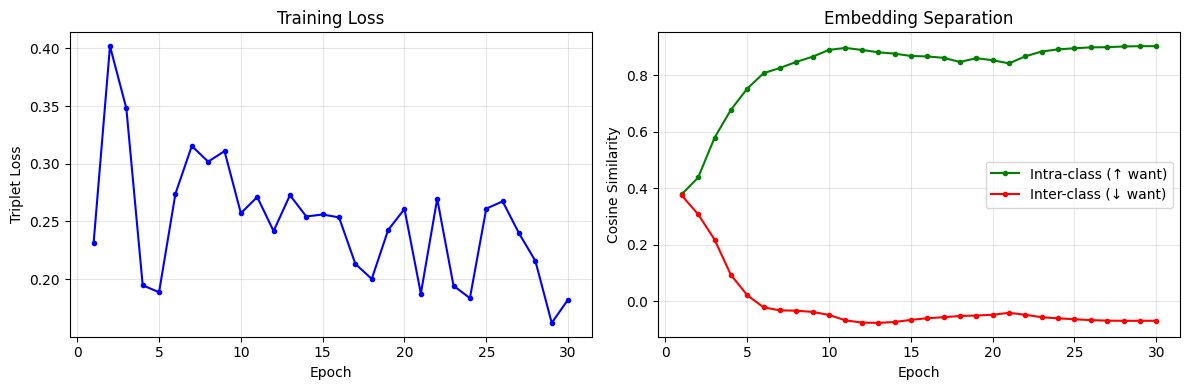

In [ ]:
# ──────────────────────────────────────────────
# 7. ENTRY POINT
# ──────────────────────────────────────────────

if __name__ == "__main__":

    # ── OPTION A: Full training with labels ──────────────────────────
    # Replace with your actual CSV directory and PHQ label mapping.
    #
    # label_map example (filename stem → PHQ class 0-4):
    #   "01-01-01-01-01-01-01" → 0  (minimal)
    #   "01-01-01-01-01-02-01" → 2  (moderate)
    #   etc.

    # CSV_DIR = "C:\Shweta\Coding\summer_intern\timesformer"
    CSV_DIR_2 = "/content/"

    # loop to create label map for all downloaded csv files
    label_map = {}
    for filename in os.listdir(CSV_DIR_2):
      if filename.endswith(".csv"):
        name = filename.replace(".csv", "")
        label_map[name] = int(name[7])
    print(label_map)
    print(len(label_map))

    # label_map = {
    #     "01-01-01-01-01-01-01": 1,
    #     "01-01-01-01-01-01-02": 1,
    #     "01-01-01-01-01-01-03": 1,
    #     "01-01-01-01-01-01-07": 1,
    #     "01-01-01-01-01-01-08": 1,
    #     "01-01-01-01-01-01-09": 1,
    #     "01-01-01-01-01-01-11": 1,
    #     # ... add all your videos with their PHQ class
    # }

    model, history = train(
        csv_dir=CSV_DIR_2,
        label_map=label_map,
        num_epochs=30,
        batch_size=8,
        margin=0.3,
    )
    plot_training(history)

    # ── OPTION B: Quick same-label sanity check (like your notebook) ──
    # csv_paths = [
    #     "01-01-01-01-01-01-01.csv",
    #     "01-01-01-01-01-01-02.csv",
    #     "01-01-01-01-01-01-03.csv",
    #     "01-01-01-01-01-01-07.csv",
    #     "01-01-01-01-01-01-08.csv",
    #     "01-01-01-01-01-01-09.csv",
    #     "01-01-01-01-01-01-11.csv",
    # ]
    # quick_test_same_label(csv_paths, label=1)

In [ ]:
best_intra = 0
for epoch in range(1, num_epochs + 1):
    ...
    if stats["intra_mean"] - abs(stats["inter_mean"]) > best_score:
        best_score = stats["intra_mean"] - abs(stats["inter_mean"])
        torch.save(model.state_dict(), "best_model.pt")

NameError: name 'num_epochs' is not defined

In [ ]:
# Freeze transformer
for param in model.parameters():
    param.requires_grad = False

# Lightweight ordinal classifier on top
classifier = nn.Sequential(
    nn.Linear(768, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 6)   # 5 PHQ severity classes
)

In [ ]:
set(label_map.values())

{1, 4, 5, 6, 7, 8}

In [ ]:
def ravdess_label_map2(csv_dir: str) -> dict:
    EMOTION_TO_IDX = {1:0, 4:1, 5:2, 6:3, 7:4, 8:5}
    label_map = {}

    for fname in os.listdir(csv_dir):
        if not fname.endswith(".csv"):
            continue

        stem = fname.replace(".csv", "")
        parts = stem.split("-")

        if len(parts) < 3:
            raise ValueError(f"Bad filename format: {fname}")

        emotion = int(parts[2])

        if emotion not in EMOTION_TO_IDX:
            raise ValueError(f"Unknown emotion {emotion} in {fname}")

        label_map[stem] = EMOTION_TO_IDX[emotion]

    values = set(label_map.values())
    assert values == {0,1,2,3,4,5}, f"Bad label set: {values}"

    return label_map

In [ ]:
CSV_DIR = "/content/"
label_map_out = ravdess_label_map2(CSV_DIR)

In [ ]:
"""
Classification Head on TransformerEmbeddingExtractor
=====================================================
Two-stage pipeline:
  1. Load the Transformer trained with triplet loss (frozen)
  2. Train a lightweight classification head on its CLS embeddings

Works for any label set — swap NUM_CLASSES and label_map for your dataset.
Currently shown for RAVDESS 8-emotion classification.
For PHQ severity: set NUM_CLASSES = 5.
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# ──────────────────────────────────────────────
# 1. TRANSFORMER BACKBONE (unchanged)
# ──────────────────────────────────────────────

class TransformerEmbeddingExtractor(nn.Module):
    def __init__(self, input_dim=512, embed_dim=768, num_heads=12, num_layers=4):
        super().__init__()
        self.proj = nn.Linear(input_dim, embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(0)
        x = self.proj(x)
        batch_size = x.size(0)
        cls = self.cls_token.unsqueeze(0).expand(batch_size, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.encoder(x)
        return x[:, 0]   # (B, 768)


# ──────────────────────────────────────────────
# 2. CLASSIFICATION HEAD
# ──────────────────────────────────────────────

class ClassificationHead(nn.Module):
    """
    Sits on top of the frozen Transformer's CLS embedding.
    embed_dim  : must match TransformerEmbeddingExtractor's embed_dim (768)
    num_classes: 8 for RAVDESS emotions | 5 for PHQ severity
    """
    def __init__(self, embed_dim=768, num_classes=8, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)   # (B, num_classes) — raw logits


class FullModel(nn.Module):
    """
    Backbone + head in one module.
    Use freeze_backbone=True during Stage 1 (head-only training).
    Set freeze_backbone=False for Stage 2 (optional end-to-end fine-tuning).
    """
    def __init__(self, backbone: TransformerEmbeddingExtractor,
                 num_classes: int, dropout=0.3, freeze_backbone=True):
        super().__init__()
        self.backbone = backbone
        self.head = ClassificationHead(768, num_classes, dropout)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        emb = self.backbone(x)    # (B, 768)
        return self.head(emb)     # (B, num_classes)

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


# ──────────────────────────────────────────────
# 3. DATASET
# ──────────────────────────────────────────────

class VideoEmbeddingDataset(Dataset):
    """
    csv_dir  : folder of per-video ArcFace CSVs
    label_map: {filename_stem: integer_label}

    RAVDESS filename format: 01-01-02-01-01-01-01.csv
      position 3 (0-indexed) = emotion (1–8)
      → label = int(stem.split('-')[2]) - 1   (0-indexed)

    For PHQ: build label_map manually from your metadata file.
    """
    def __init__(self, csv_dir: str, label_map: dict):
        self.samples = []
        missing = []
        for fname in sorted(os.listdir(csv_dir)):
            if not fname.endswith(".csv"):
                continue
            stem = fname.replace(".csv", "")
            if stem not in label_map:
                missing.append(stem)
                continue
            arr = pd.read_csv(os.path.join(csv_dir, fname)).values.astype(np.float32)
            self.samples.append((torch.tensor(arr), label_map[stem]))
        if missing:
            print(f"[Dataset] Skipped {len(missing)} files not in label_map.")
        print(f"[Dataset] Loaded {len(self.samples)} videos.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_pad(batch):
    tensors, labels = zip(*batch)
    max_len = max(t.shape[0] for t in tensors)
    padded = torch.zeros(len(tensors), max_len, tensors[0].shape[1])
    for i, t in enumerate(tensors):
        padded[i, :t.shape[0]] = t
    return padded, torch.tensor(labels, dtype=torch.long)


# ──────────────────────────────────────────────
# 4. LABEL MAP HELPERS
# ──────────────────────────────────────────────

def ravdess_label_map(csv_dir: str) -> dict:
    EMOTION_TO_IDX = {1:0, 4:1, 5:2, 6:3, 7:4, 8:5}
    label_map = {}
    for fname in os.listdir(csv_dir):
        if not fname.endswith(".csv"):
            continue
        stem = fname.replace(".csv", "")
        parts = stem.split("-")
        if len(parts) >= 3:
            emotion = int(parts[2])
            if emotion in EMOTION_TO_IDX:
                label_map[stem] = EMOTION_TO_IDX[emotion]

    return label_map
# label_map = ravdess_label_map(csv_dir)
# print(set(label_map.values()))  # must print {0, 1, 2, 3, 4, 5} — nothing else




# For PHQ severity — build manually:
# label_map = {
#     "P300": 0,   # minimal
#     "P301": 2,   # moderate
#     ...
# }


# ──────────────────────────────────────────────
# 5. TRAINING
# ──────────────────────────────────────────────

def train_classifier(
    csv_dir: str,
    backbone_weights: str,            # path to transformer_triplet.pt
    num_classes: int = 8,             # 8 for RAVDESS, 5 for PHQ
    label_map: dict = None,           # if None, auto-builds from RAVDESS filenames
    val_split: float = 0.2,
    batch_size: int = 8,
    epochs_frozen: int = 20,          # Stage 1: head only
    epochs_unfrozen: int = 10,        # Stage 2: end-to-end (set 0 to skip)
    lr_head: float = 1e-3,
    lr_finetune: float = 1e-5,
    dropout: float = 0.3,
    save_path: str = "full_model.pt",
    device: str = None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # # Label map
    if label_map is None:
        label_map = ravdess_label_map(csv_dir)
        print(f"Auto-built RAVDESS label map: {len(label_map)} entries")

    # Dataset + split
    dataset = VideoEmbeddingDataset(csv_dir, label_map)
    n_val   = max(1, int(len(dataset) * val_split))
    print("here")
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(dataset, [n_train, n_val])
    print("here1")
    train_dl = DataLoader(train_ds, batch_size=batch_size,
                          shuffle=True,  collate_fn=collate_pad)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size,
                          shuffle=False, collate_fn=collate_pad)

    # Load backbone
    backbone = TransformerEmbeddingExtractor().to(device)
    print("here2")
    backbone.load_state_dict(torch.load(backbone_weights, map_location=device))
    print(f"Loaded backbone from {backbone_weights}")

    model = FullModel(backbone, num_classes, dropout, freeze_backbone=True).to(device)

    history = []

    # ── Stage 1: train head only ──────────────
    print(f"\n── Stage 1: head-only ({epochs_frozen} epochs) ──")
    optimizer = torch.optim.AdamW(model.head.parameters(), lr=lr_head)
    history += _run_epochs(model, train_dl, val_dl, optimizer,
                           epochs_frozen, device, label="S1")

    # ── Stage 2: end-to-end fine-tune ─────────
    if epochs_unfrozen > 0:
        print(f"\n── Stage 2: end-to-end fine-tune ({epochs_unfrozen} epochs) ──")
        model.unfreeze_backbone()
        optimizer = torch.optim.AdamW([
            {"params": model.backbone.parameters(), "lr": lr_finetune},
            {"params": model.head.parameters(),     "lr": lr_head * 0.1},
        ])
        history += _run_epochs(model, train_dl, val_dl, optimizer,
                               epochs_unfrozen, device, label="S2")

    torch.save(model.state_dict(), save_path)
    print(f"\nSaved to {save_path}")

    _plot_history(history)
    _evaluate(model, val_dl, device, num_classes)
    return model


def _run_epochs(model, train_dl, val_dl, optimizer, n_epochs, device, label=""):
    history = []
    loss_fn = nn.CrossEntropyLoss()
    for ep in range(1, n_epochs + 1):
        # train
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = loss_fn(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * len(y)
            t_correct += (logits.argmax(1) == y).sum().item()
            t_total   += len(y)

        # val
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                v_loss    += loss_fn(logits, y).item() * len(y)
                v_correct += (logits.argmax(1) == y).sum().item()
                v_total   += len(y)

        row = {
            "epoch":    f"{label}-{ep}",
            "t_loss":   t_loss / t_total,
            "t_acc":    t_correct / t_total,
            "v_loss":   v_loss / v_total,
            "v_acc":    v_correct / v_total,
        }
        history.append(row)
        print(f"[{row['epoch']:6s}] "
              f"train loss={row['t_loss']:.4f} acc={row['t_acc']:.3f} | "
              f"val   loss={row['v_loss']:.4f} acc={row['v_acc']:.3f}")
    return history


# ──────────────────────────────────────────────
# 6. EVALUATION
# ──────────────────────────────────────────────

# RAVDESS_LABELS = ["neutral","calm","happy","sad","angry","fearful","disgust","surprised"]
RAVDESS_LABELS = ["neutral", "sad", "angry", "fearful", "disgust", "surprised"]
# emotions 1, 4, 5, 6, 7, 8 respectively
PHQ_LABELS     = ["minimal","mild","moderate","moderately severe","severe"]

@torch.no_grad()
def _evaluate(model, dataloader, device, num_classes):
    model.eval()
    all_preds, all_true = [], []
    for x, y in dataloader:
        preds = model(x.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(y.numpy())

    # labels = RAVDESS_LABELS[:num_classes] if num_classes == 8 else PHQ_LABELS[:num_classes]
    labels = RAVDESS_LABELS[:num_classes]
    print("\n=== Classification Report ===")
    print(classification_report(all_true, all_preds, target_names=labels, zero_division=0))

    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
                cmap="Blues")
    plt.title("Confusion Matrix"); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()


def _plot_history(history):
    epochs = [h["epoch"] for h in history]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot([h["t_loss"] for h in history], label="train")
    ax1.plot([h["v_loss"] for h in history], label="val")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot([h["t_acc"] for h in history], label="train")
    ax2.plot([h["v_acc"] for h in history], label="val")
    ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
    # mark stage boundary
    s2_start = next((i for i, h in enumerate(history) if h["epoch"].startswith("S2")), None)
    if s2_start:
        ax1.axvline(s2_start, color="red", linestyle="--", alpha=0.5, label="unfreeze")
        ax2.axvline(s2_start, color="red", linestyle="--", alpha=0.5, label="unfreeze")
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()


# ──────────────────────────────────────────────
# 7. INFERENCE
# ──────────────────────────────────────────────

@torch.no_grad()
def predict(model, csv_path: str, device="cpu", num_classes=8):
    """Predict class for a single video CSV."""
    arr = pd.read_csv(csv_path).values.astype(np.float32)
    x   = torch.tensor(arr).unsqueeze(0).to(device)   # (1, T, 512)
    model.eval()
    logits = model(x)
    probs  = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred   = probs.argmax()
    labels = RAVDESS_LABELS if num_classes == 8 else PHQ_LABELS
    print(f"Predicted: {labels[pred]} (class {pred})")
    print("Probabilities:")
    for i, (l, p) in enumerate(zip(labels[:num_classes], probs)):
        bar = "█" * int(p * 30)
        print(f"  {l:20s} {p:.3f} {bar}")
    return pred, probs


# ──────────────────────────────────────────────
# 8. ENTRY POINT
# ──────────────────────────────────────────────

if __name__ == "__main__":

    CSV_DIR          = "/content/"
    BACKBONE_WEIGHTS = "transformer_triplet.pt"         # from triplet training
    NUM_CLASSES      = 6    # RAVDESS emotions | swap to 5 for PHQ severity
    all_labels = list(label_map_out.values())

    print("Labels:", sorted(set(all_labels)))
    print("Min/Max:", min(all_labels), max(all_labels))
    assert min(all_labels) == 0
    assert max(all_labels) == 5
    print("started")
    model = train_classifier(
        csv_dir          = CSV_DIR,
        backbone_weights = BACKBONE_WEIGHTS,
        num_classes      = NUM_CLASSES,
        label_map        = label_map_out,          # auto-builds from RAVDESS filenames
        val_split        = 0.2,
        batch_size       = 8,
        epochs_frozen    = 20,
        epochs_unfrozen  = 10,
        lr_head          = 1e-3,
        lr_finetune      = 1e-5,
    )

    # Single-video inference
    # pred, probs = predict(model, "01-01-03-01-01-01-01.csv", num_classes=NUM_CLASSES)


Labels: [0, 1, 2, 3, 4, 5]
Min/Max: 0 5
started
Device: cuda
[Dataset] Loaded 42 videos.
here
here1


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
# Then run your PyTorch code here

In [ ]:
def ravdess_label_map(csv_dir: str) -> dict:
    EMOTION_TO_IDX = {1:0, 4:1, 5:2, 6:3, 7:4, 8:5}
    label_map = {}
    for fname in os.listdir(csv_dir):
        if not fname.endswith(".csv"):
            continue
        stem = fname.replace(".csv", "")
        parts = stem.split("-")
        if len(parts) >= 3:
            emotion = int(parts[2])
            if emotion in EMOTION_TO_IDX:
                label_map[stem] = EMOTION_TO_IDX[emotion]
      # must print {0, 1, 2, 3, 4, 5} — nothing else
    return label_map
    label_map = ravdess_label_map(csv_dir)
    print(set(label_map.values()))

In [ ]:
label_map_out

{'01-01-07-02-02-01-24': 4,
 '01-01-04-02-02-01-11': 1,
 '01-01-06-02-02-01-19': 3,
 '01-01-06-02-02-01-22': 3,
 '01-01-08-02-02-01-18': 5,
 '01-01-05-02-02-01-17': 2,
 '01-01-06-02-02-01-21': 3,
 '01-01-06-02-02-01-24': 3,
 '01-01-08-02-02-01-20': 5,
 '01-01-07-02-02-01-20': 4,
 '01-01-06-02-02-01-18': 3,
 '01-01-04-02-02-01-09': 1,
 '01-01-05-02-02-01-16': 2,
 '01-01-01-01-01-01-01': 0,
 '01-01-04-02-02-01-08': 1,
 '01-01-01-01-01-01-02': 0,
 '01-01-01-01-01-01-09': 0,
 '01-01-08-02-02-01-19': 5,
 '01-01-06-02-02-01-20': 3,
 '01-01-08-02-02-01-24': 5,
 '01-01-01-01-01-01-07': 0,
 '01-01-01-01-01-01-11': 0,
 '01-01-06-02-02-01-23': 3,
 '01-01-05-02-02-01-11': 2,
 '01-01-07-02-02-01-23': 4,
 '01-01-05-02-02-01-13': 2,
 '01-01-07-02-02-01-19': 4,
 '01-01-07-02-02-01-21': 4,
 '01-01-04-02-02-01-07': 1,
 '01-01-07-02-02-01-18': 4,
 '01-01-08-02-02-01-23': 5,
 '01-01-07-02-02-01-22': 4,
 '01-01-05-02-02-01-12': 2,
 '01-01-01-01-01-01-08': 0,
 '01-01-05-02-02-01-14': 2,
 '01-01-08-02-02-01-